# Building Models for Regression for Power Plant Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

# ANN - Artificial Neural Network

## Step 1. Load the Dataset

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
print(df.shape)
df.head() # Temp, Vacuum, Pressure, Humidity, Produced_Energy

(9568, 5)


,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
X = df.drop("PE", axis=1)
y = df["PE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 2. Convert the data to Tensor

In [5]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32) #X_train_scaled is a numpy array
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1) #y_train is a pd series, but we need an np array
# view(row,col), col=-1 means automatically detect. So, Total rows = total values in y_train
# We have to convert it into 2D numpy array

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

## Step 3. Create Tensor Dataset Object

In [6]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

## Create Data Loader Object

In [7]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Step 4. Deep Learning => Define ANN Model

In [8]:
# For sample, we are defining 2 hidden layers, with 6 neurons each => Refer the 1st img in Neural Network Doc in Google Drive

class ANN(nn.Module): # nn.Module is the base class and it contains the mechanisms of PyTorch
    def __init__(self):
        super(ANN, self).__init__() # Call the constructor of nn.Module

        self.model = nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(in_features=X_train.shape[1], out_features=6), # Calculate z = wi.xi + b
            nn.ReLU(),
    
            # 2nd Hidden Layer
            nn.Linear(in_features=6, out_features=6),
            nn.ReLU(),
    
            # Output Layer
            nn.Linear(in_features=6, out_features=1)
        )

    # Forward Propagation
    def forward(self, x):
        return self.model(x)

    # Backward Propagation is handled by Autograd in PyTorch at the Backend

In [9]:
model = ANN()

# Loss func()
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model.parameters())

## Step 4. Train the Model & Saving the Best Model

In [10]:
# We are passing the train_data for 100 times (100 eopchs)
epochs = 100
train_losses = []
valid_losses = [] # Validation
best_val = float("inf") # Infinity

for epoch in range(epochs):
    model.train()

    running_loss = 0.0 # Saves the total training loss of 1 epoch

    for xb,yb in train_loader: # To pass batches
        # xb = features
        # yb = labels

        # Training
        optimizer.zero_grad() # To re-initialise the gradient, as by default it accumulates the calculated gradients
        
        # Forward Propagartion
        outputs = model(xb) # Predicted outputs for the batch

        # Loss Calculation
        loss = criterion(outputs, yb)

        # Back Propagation
        loss.backward() # Computes Gradients
        
        optimizer.step() # It updates the parameters

        running_loss += loss.item() # Converts loss type from tensor to float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    
    running_valid_loss = 0.0

    with torch.no_grad(): # torch doesn't need to compute gradients while validation
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_valid_loss += loss.item() # Converts loss type from tensor to float

    epoch_test_loss = running_valid_loss / len(test_loader)
    valid_losses.append(epoch_test_loss)

    # Saving & Loading the Best Model
    if epoch_test_loss < best_val:
        best_val = epoch_test_loss
        torch.save(model.state_dict(), "best_ANN_model.pt") # .pt or .pth
        

    # Printing Training Loss & Validation Loss for each epoch
    print(f"Epoch: {epoch+1}/{epochs}")
    print(f"Training Loss: {epoch_train_loss}")
    print(f"Testing Loss: {epoch_test_loss}")
    print("*"*120)

Epoch: 1/100
Training Loss: 205571.09609375
Testing Loss: 203044.38177083334
************************************************************************************************************************
Epoch: 2/100
Training Loss: 195618.9763671875
Testing Loss: 183608.94375
************************************************************************************************************************
Epoch: 3/100
Training Loss: 162907.38955078126
Testing Loss: 138193.3421875
************************************************************************************************************************
Epoch: 4/100
Training Loss: 109835.31650390624
Testing Loss: 82034.92434895833
************************************************************************************************************************
Epoch: 5/100
Training Loss: 59918.234375
Testing Loss: 42282.04951171875
************************************************************************************************************************
Epoch: 6/100
Trai

## Visualising Losses

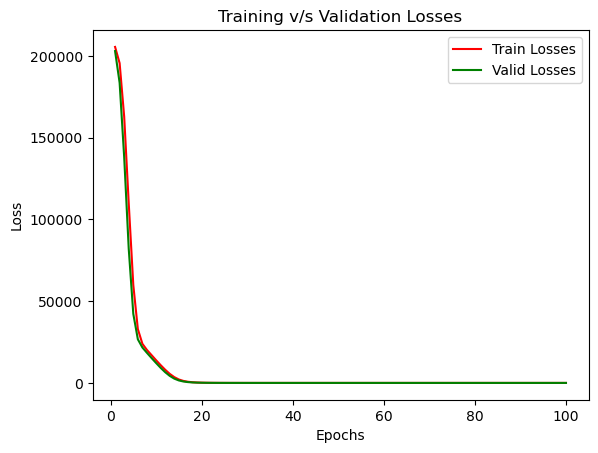

In [11]:
loss_df = pd.DataFrame({
    "Epoch": range(1,epochs+1),
    "Training Loss": train_losses,
    "Validation Loss": valid_losses
})

sns.lineplot(
    data = loss_df,
    y = "Training Loss",
    x = "Epoch",
    color = "red",
    label = "Train Losses"
)
sns.lineplot(
    data = loss_df,
    x = "Epoch",
    y = "Validation Loss",
    color = "green",
    label = "Valid Losses"
)

plt.title("Training v/s Validation Losses")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()

In [12]:
idx = np.argmin(valid_losses)
print("Best Model Parameters")
print("Epoch:", idx+1)
print("Training Loss:", train_losses[idx])
print("Validation Loss:", valid_losses[idx])

Best Model Parameters
Epoch: 94
Training Loss: 20.920656232039132
Validation Loss: 18.83180085817973


## Step 5. Load the Best Model

In [13]:
model.load_state_dict(torch.load("best_ANN_model.pt"))

<All keys matched successfully>

## Step 6. Model Evaluation

In [14]:
model.eval()

with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = criterion(train_pred, y_train_tensor)
    test_mse_loss = criterion(test_pred, y_test_tensor)

print("Train MSE Loss:", train_mse_loss.item())
print("Test MSE Loss:", test_mse_loss.item())
print()
print("Train R2 Score:", r2_score(y_train, train_pred))
print("Test R2 Score:", r2_score(y_test, test_pred))      

Train MSE Loss: 20.525798797607422
Test MSE Loss: 18.83797836303711

Train R2 Score: 0.9298315991924799
Test R2 Score: 0.9341661318177655


In [15]:
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])
predicted_df = pd.DataFrame(test_pred.numpy(), columns=["Predicted Values"])
pd.concat([actual_df,predicted_df], axis=1)

,Actual Values,Predicted Values
0,433.27,434.953888
1,438.16,437.218994
2,458.42,461.352356
3,480.82,476.579895
4,441.41,435.228607
...,...,...
1909,456.70,451.402588
1910,438.04,431.637909
1911,467.80,467.396088
1912,437.14,431.174835


# Linear Regression with Regularisation

In [16]:
# Hyperparameter Tuning
param_grid = {
    "alpha": [0.001, 0.01, 0.1, 0.5, 1, 10],
    "l1_ratio": np.linspace(0.1,0.9,9)
}

# Model
elastic_model = ElasticNet(max_iter=10000)

grid_search = GridSearchCV(
    estimator = elastic_model,
    param_grid = param_grid,
    scoring = "r2",
    cv = 5,
    n_jobs = -1
)

# Training the Best Model
grid_search.fit(X_train_scaled, y_train)

,estimator,ElasticNet(max_iter=10000)
,param_grid,"{'alpha': [0.001, 0.01, ...], 'l1_ratio': array([0.1, 0....7, 0.8, 0.9])}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.001


In [17]:
# Predictions
y_train_pred = grid_search.predict(X_train_scaled)
y_test_pred = grid_search.predict(X_test_scaled)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation r2 score (Avg.):", grid_search.best_score_)
print("Train r2 score:", r2_score(y_train, y_train_pred))
print("Test r2 score:", r2_score(y_test, y_test_pred))

Best Parameters: {'alpha': 0.001, 'l1_ratio': np.float64(0.9)}
Best Cross Validation r2 score (Avg.): 0.9278616162837512
Train r2 score: 0.9279951185746068
Test r2 score: 0.9314743281670353


# KNN - K Nearest Neighbours

In [18]:
# Hyperparameter Tuning
param_grid = {
    "n_neighbors": [3,5,7,9]
}

# Model
knn = KNeighborsRegressor()

grid_search = GridSearchCV(
    estimator = knn,
    param_grid = param_grid,
    scoring = "r2",
    cv = 5,
    n_jobs = -1
)

# Training the Best Model
grid_search.fit(X_train_scaled, y_train)

,estimator,KNeighborsRegressor()
,param_grid,"{'n_neighbors': [3, 5, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,5


In [19]:
# Predictions
y_train_pred = grid_search.predict(X_train_scaled)
y_test_pred = grid_search.predict(X_test_scaled)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation r2 score (Avg.):", grid_search.best_score_)
print("Train r2 score:", r2_score(y_train, y_train_pred))
print("Test r2 score:", r2_score(y_test, y_test_pred))

Best Parameters: {'n_neighbors': 5}
Best Cross Validation r2 score (Avg.): 0.9472838363176784
Train r2 score: 0.9673065853726502
Test r2 score: 0.9521517965621104


# SVM - Search Vector Machine

In [20]:
# Model
svr = SVR(
    kernel = "rbf",
    epsilon = 0.1,
    C = 1.0
)

# Training the Best Model
svr.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [21]:
# Predictions
y_train_pred = svr.predict(X_train_scaled)
y_test_pred = svr.predict(X_test_scaled)

print("Train r2 score:", r2_score(y_train, y_train_pred))
print("Test r2 score:", r2_score(y_test, y_test_pred))

Train r2 score: 0.9403984549767179
Test r2 score: 0.943254533099243


# Decision Tree Regressor

In [22]:
# Hyperparameter Tuning
param_grid = {
    "max_depth": [None, 3, 5, 7, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "ccp_alpha": [0.0, 0.001, 0.01, 0.1]
}

# Model 
dtr = DecisionTreeRegressor(
    random_state = 42
)

grid_search = GridSearchCV(
    estimator = dtr,
    param_grid = param_grid,
    scoring = "r2",
    cv = 5,
    n_jobs = -1
)

# Training the Best Model
grid_search.fit(X_train_scaled, y_train)

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'ccp_alpha': [0.0, 0.001, ...], 'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [23]:
# Predictions
y_train_pred = grid_search.predict(X_train_scaled)
y_test_pred = grid_search.predict(X_test_scaled)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation r2 score (Avg.):", grid_search.best_score_)
print("Train r2 score:", r2_score(y_train, y_train_pred))
print("Test r2 score:", r2_score(y_test, y_test_pred))

Best Parameters: {'ccp_alpha': 0.01, 'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 20}
Best Cross Validation r2 score (Avg.): 0.9425543002325385
Train r2 score: 0.9668426379237154
Test r2 score: 0.9466267277278858


# Random Forest Regressor

In [24]:
# Hyperparameter Tuning
param_grid = {
    "max_depth": [2,4,6,7],
    "min_samples_split": [2,4,5,6]
}

# Model
rf = RandomForestRegressor(
    n_estimators = 201,
    random_state = 42,
    bootstrap = True
)

grid_search = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    scoring = "r2",
    cv = 5,
    n_jobs = -1
)

# Training the Best Model
grid_search.fit(X_train_scaled, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [2, 4, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,201


In [25]:
# Predictions
y_train_pred = grid_search.predict(X_train_scaled)
y_test_pred = grid_search.predict(X_test_scaled)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation r2 score (Avg.):", grid_search.best_score_)
print("Train r2 score:", r2_score(y_train, y_train_pred))
print("Test r2 score:", r2_score(y_test, y_test_pred))

Best Parameters: {'max_depth': 7, 'min_samples_split': 5}
Best Cross Validation r2 score (Avg.): 0.9479263689896742
Train r2 score: 0.957946509397167
Test r2 score: 0.9520693139002041


# AdaBoost Regressor

In [26]:
# Base Model
dtr = DecisionTreeRegressor(
    random_state = 42
)

# Hyperparameter Tuning
param_grid = {
    "n_estimators": [201,501],
    "learning_rate": [0.01,0.1,1],
    "estimator__max_depth": [2,5],
    "estimator__min_samples_split": [2,5,10],
    "estimator__min_samples_leaf": [1,2,4]
}

# Model
ada = AdaBoostRegressor(
    estimator = dtr,
    random_state = 42
)

grid_search = GridSearchCV(
    estimator = ada,
    param_grid = param_grid,
    scoring = "r2",
    cv = 3,
    n_jobs = -1
)

# Training the Best Model
grid_search.fit(X_train_scaled, y_train)

,estimator,AdaBoostRegre...ndom_state=42)
,param_grid,"{'estimator__max_depth': [2, 5], 'estimator__min_samples_leaf': [1, 2, ...], 'estimator__min_samples_split': [2, 5, ...], 'learning_rate': [0.01, 0.1, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [27]:
# Predictions
y_train_pred = grid_search.predict(X_train_scaled)
y_test_pred = grid_search.predict(X_test_scaled)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation r2 score (Avg.):", grid_search.best_score_)
print("Train r2 score:", r2_score(y_train, y_train_pred))
print("Test r2 score:", r2_score(y_test, y_test_pred))

Best Parameters: {'estimator__max_depth': 5, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 10, 'learning_rate': 0.01, 'n_estimators': 501}
Best Cross Validation r2 score (Avg.): 0.9383292787189886
Train r2 score: 0.9435748282744435
Test r2 score: 0.942555190072073


# Gradient Boosting Regressor

In [28]:
# Hyperparameter Tuning
param_grid = {
    "n_estimators": [201, 501],
    "learning_rate": [0.01, 0.1],
    "max_depth": [2, 3, 5],
    "min_samples_split": [2, 5],
    "subsample": [0.8, 1.0]
}

# Model
gbr = GradientBoostingRegressor(
    random_state = 42
)

grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    scoring="r2",
    cv=3,
    n_jobs=-1
)

# Training the Best Model
grid_search.fit(X_train_scaled, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.1], 'max_depth': [2, 3, ...], 'min_samples_split': [2, 5], 'n_estimators': [201, 501], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [29]:
# Predictions
y_train_pred = grid_search.predict(X_train_scaled)
y_test_pred = grid_search.predict(X_test_scaled)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation r2 score (Avg.):", grid_search.best_score_)
print("Train r2 score:", r2_score(y_train, y_train_pred))
print("Test r2 score:", r2_score(y_test, y_test_pred))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 501, 'subsample': 0.8}
Best Cross Validation r2 score (Avg.): 0.9625004018344727
Train r2 score: 0.989890320964745
Test r2 score: 0.9700774095322404


# Stacking

In [30]:
# Base Models
base_models = [
    ("rf", RandomForestRegressor(
        max_depth = 7, 
        min_samples_split = 5,
        n_estimators = 201,
        random_state = 42
    )),

    ("gb", GradientBoostingRegressor(
        n_estimators = 501,
        max_depth = 5,
        min_samples_split = 5,
        subsample = 0.8,
        learning_rate = 0.1,
        random_state = 42
    )),

    ("svr", SVR(
        kernel = "rbf",
        epsilon = 0.1,
        C = 1.0
    ))
]

# Stack Model
stacking_model = StackingRegressor(
    estimators = base_models,
    final_estimator = Ridge(),
    cv = 5,
    n_jobs = -1
)

# Training the Model
stacking_model.fit(X_train_scaled, y_train)

,estimators,"[('rf', ...), ('gb', ...), ...]"
,final_estimator,Ridge()
,cv,5
,n_jobs,-1
,passthrough,False
,verbose,0
,n_estimators,201
,criterion,'squared_error'
,max_depth,7
,min_samples_split,5
,min_samples_leaf,1


In [31]:
# Predictions
y_train_pred = stacking_model.predict(X_train_scaled)
y_test_pred = stacking_model.predict(X_test_scaled)

print("Train r2 score:", r2_score(y_train, y_train_pred))
print("Test r2 score:", r2_score(y_test, y_test_pred))

Train r2 score: 0.9911167937215102
Test r2 score: 0.9702494481846271


# Conclusion

In [32]:
conclusion_df = pd.DataFrame({
    "Model": ["ANN", "Linear Regression", "KNN", "SVM", "Decision Tree", "Random Forest", "AdaBoost", "Gradient Boost", "Stacking"],
    "Train r2 Score": [0.9277, 0.9279, 0.9673, 0.9403, 0.9668, 0.9579, 0.9435, 0.9898, 0.9911],
    "Test r2 Score": [0.9315, 0.9314, 0.9521, 0.9432, 0.9466, 0.9520, 0.9425, 0.9700, 0.9702]
})
conclusion_df

,Model,Train r2 Score,Test r2 Score
0,ANN,0.9277,0.9315
1,Linear Regression,0.9279,0.9314
2,KNN,0.9673,0.9521
3,SVM,0.9403,0.9432
4,Decision Tree,0.9668,0.9466
5,Random Forest,0.9579,0.9520
6,AdaBoost,0.9435,0.9425
7,Gradient Boost,0.9898,0.9700
8,Stacking,0.9911,0.9702
